In [715]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [716]:
data = pd.read_csv(r'D:\Machine Learning\Standardization\Social_Network_Ads.csv')

In [717]:
data = data.iloc[:,2:]

In [718]:
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [719]:
x = data.drop('Purchased',axis=1)
y = data['Purchased']

## Train Test Split

In [720]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

X_train.shape, X_test.shape

((280, 2), (120, 2))

## Standardization

In [721]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [722]:
scaler.mean_

array([3.77285714e+01, 6.95785714e+04])

In [723]:
X_train_scaled

array([[-0.65684947,  0.04307329],
       [-0.55922853,  1.43700292],
       [ 1.78367403, -0.29025771],
       [ 0.22173899,  0.25519302],
       [ 0.80746463,  0.13398175],
       [-0.75447041,  0.58852402],
       [ 0.31935993, -0.32056053],
       [-1.63305886, -1.6235817 ],
       [ 0.31935993, -0.53268025],
       [-0.26636571,  0.07337611],
       [ 0.41698087,  0.61882683],
       [-0.55922853,  2.43699592],
       [ 1.39319027,  1.34609447],
       [ 1.10032745, -1.25994789],
       [-1.7306798 , -1.41146198],
       [ 2.07653685,  0.19458738],
       [ 0.41698087,  0.28549584],
       [-0.07112383, -0.50237743],
       [-0.26636571, -1.44176479],
       [-0.26636571, -0.13874362],
       [-0.16874477, -0.59328589],
       [-0.36398665, -0.80540561],
       [-0.16874477, -0.53268025],
       [ 1.97891591,  0.77034092],
       [ 0.80746463,  1.43700292],
       [ 0.31935993, -0.74479998],
       [ 1.00270651,  1.49760856],
       [ 0.12411805, -0.32056053],
       [-0.26636571,

In [724]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns= X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns= X_test.columns)

In [725]:
X_train_scaled

,Age,EstimatedSalary
0,-0.656849,0.043073
1,-0.559229,1.437003
2,1.783674,-0.290258
3,0.221739,0.255193
4,0.807465,0.133982
...,...,...
275,0.124118,0.043073
276,0.124118,0.800644
277,-1.730680,0.376404
278,0.026497,0.315799


In [726]:
np.round(X_train.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,38.0,69579.0
std,10.0,33059.0
min,18.0,15000.0
25%,30.0,46750.0
50%,37.0,70000.0
75%,46.0,86000.0
max,60.0,150000.0


In [727]:
np.round(X_train_scaled.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,-0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,0.0
75%,1.0,0.0
max,2.0,2.0


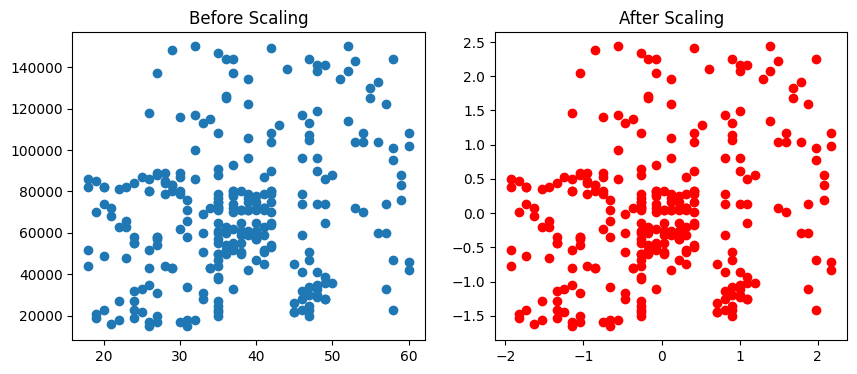

In [728]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,4 ))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

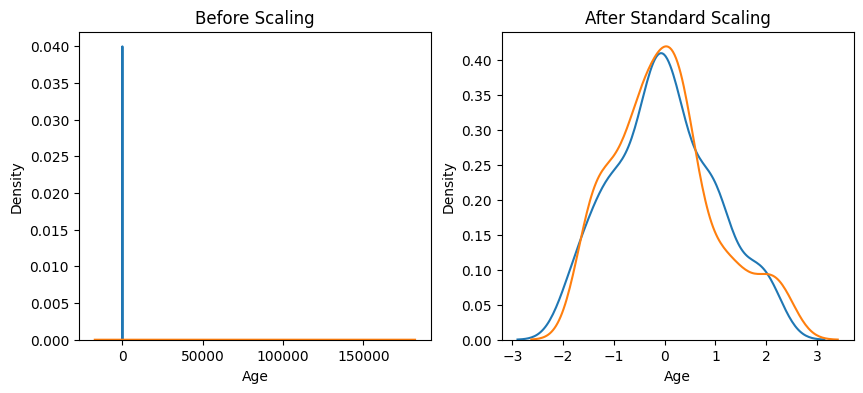

In [729]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

In [730]:
from sklearn.linear_model import LogisticRegression

In [731]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [732]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [733]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [734]:
from sklearn.metrics import accuracy_score

In [735]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.825
Scaled 0.8333333333333334
